In [1]:
import pandas as pd
from numpy.ma.core import log2, size

from marginal_emissions.core.msdr import MSDRAnalyzer

In [2]:
tennet = pd.read_csv('../data/processed/test_final_tennet', index_col=0, decimal=',')

In [3]:
analyzer = MSDRAnalyzer(tso='tennet', data=tennet, run='test1')

In [4]:
vars(analyzer)

{'root': PosixPath('/home/aklei/PycharmProjects/marginal-emissions-germany'),
 'tso': 'tennet',
 'run': 'test1',
 'scaler': StandardScaler(),
 'df':                           total_generation total_emissions
 datetime                                                  
 2022-12-31 23:00:00+00:00           282.75           372.0
 2022-12-31 23:15:00+00:00           282.75           372.0
 2022-12-31 23:30:00+00:00           282.75           372.0
 2022-12-31 23:45:00+00:00           282.75           372.0
 2023-01-01 00:00:00+00:00           281.25          393.16
 ...                                    ...             ...
 2023-01-08 00:15:00+00:00            311.5          418.33
 2023-01-08 00:30:00+00:00            311.5          418.33
 2023-01-08 00:45:00+00:00            311.0          417.52
 2023-01-08 01:00:00+00:00           309.25          412.28
 2023-01-08 01:15:00+00:00            309.5          412.68
 
 [682 rows x 2 columns],
 'window_length': 672,
 'n_jobs': -1,
 'param

In [5]:
analyzer.prepare()

[INFO][2026-02-16 22:51:13][msdr.py] Starting data preparation...
[INFO][2026-02-16 22:51:13][msdr.py] I. DATA INSPECTION
[INFO][2026-02-16 22:51:13][msdr.py] Setting index to datetime...
[INFO][2026-02-16 22:51:13][msdr.py] Setting columns to numeric...

[INSPECTION]
  - Index Type: datetime64[ns, UTC]
  - Duplicate Entries: 0
  - Total Generation Type: float64
  - Negative Generation Values: 0
  - Total Emissions Type: float64
  - Negative Emissions Values: 0
  - Rows with NaN Values: 0

[INFO][2026-02-16 22:51:13][msdr.py] II. DATA PREPARATION
[INFO][2026-02-16 22:51:13][msdr.py] 1) Calculation delta for time series:
[INFO][2026-02-16 22:51:13][msdr.py] Setting index to datetime...
[INFO][2026-02-16 22:51:13][msdr.py] Setting columns to numeric...
                           total_generation  total_emissions
datetime                                                    
2022-12-31 23:15:00+00:00               0.0             0.00
2022-12-31 23:30:00+00:00               0.0             

,total_generation,total_emissions
datetime,,
2022-12-31 23:15:00+00:00,-0.003781,-0.005126
2022-12-31 23:30:00+00:00,-0.003781,-0.005126
2022-12-31 23:45:00+00:00,-0.003781,-0.005126
2023-01-01 00:00:00+00:00,-0.148174,1.810557
2023-01-01 00:15:00+00:00,-0.003781,-0.005126
...,...,...
2023-01-08 00:15:00+00:00,-0.003781,-0.005126
2023-01-08 00:30:00+00:00,-0.003781,-0.005126
2023-01-08 00:45:00+00:00,-0.051912,-0.074630


In [6]:
analyzer.fit()

[INFO][2026-02-16 22:51:13][msdr.py] Starting MSDR analysis for tennet on 10 rows...


Analyzing tennet...: 100%|██████████| 10/10 [00:00<00:00, 610.78it/s]


[INFO][2026-02-16 22:51:25][msdr.py] Analysis for tennet complete.



In [7]:
analyzer.compute()

[INFO][2026-02-16 22:51:25][msdr.py] Computing MEF from best models...
[INFO][2026-02-16 22:51:25][msdr.py] Dataframe saved to /home/aklei/PycharmProjects/marginal-emissions-germany/results/tennet_run_test1/tables/df_best_coefficients.csv
[INFO][2026-02-16 22:51:25][msdr.py] Dataframe saved to /home/aklei/PycharmProjects/marginal-emissions-germany/results/tennet_run_test1/tables/df_mef_scaled.csv
[INFO][2026-02-16 22:51:25][msdr.py] Dataframe saved to /home/aklei/PycharmProjects/marginal-emissions-germany/results/tennet_run_test1/summary/summary.pkl
[INFO][2026-02-16 22:51:25][msdr.py] Inverse transforming coefficients to get absolute MEF
[INFO][2026-02-16 22:51:25][msdr.py] Dataframe saved to /home/aklei/PycharmProjects/marginal-emissions-germany/results/tennet_run_test1/tables/df_mef_absolute.csv


In [8]:
analyzer.merge_mef().dropna()

[INFO][2026-02-16 22:51:25][msdr.py] Merging MEF back to original data...
[INFO][2026-02-16 22:51:25][msdr.py] Dataframe saved to /home/aklei/PycharmProjects/marginal-emissions-germany/results/tennet_run_test1/tables/df_mef_final.csv


,total_generation,total_emissions,mef_t_MWh,mef_g_kWh,intercept
datetime,,,,,
2023-01-07 23:00:00+00:00,311.50,391.63,0.688401,688.400535,-8.541862e-02
2023-01-07 23:15:00+00:00,311.50,391.63,0.672771,672.770742,-3.916971e-13
2023-01-07 23:30:00+00:00,311.50,391.63,0.888734,888.734376,1.253405e-02
2023-01-07 23:45:00+00:00,311.50,391.63,0.677967,677.967245,-1.031814e-14
2023-01-08 00:00:00+00:00,311.50,418.33,0.699337,699.336668,-2.717803e-01
2023-01-08 00:15:00+00:00,311.50,418.33,0.677445,677.445302,6.487911e-12
2023-01-08 00:30:00+00:00,311.50,418.33,0.676405,676.404667,2.336221e-13
2023-01-08 00:45:00+00:00,311.00,417.52,0.884946,884.946440,6.095939e-02
2023-01-08 01:00:00+00:00,309.25,412.28,0.689317,689.316560,-3.533607e-01


In [9]:
analyzer.predict()

[INFO][2026-02-16 22:51:25][msdr.py] Performing in-sample prediction with best models...
[INFO][2026-02-16 22:51:26][msdr.py] Plotting estimated emissions...
[INFO][2026-02-16 22:51:26][msdr.py] Dataframe saved to /home/aklei/PycharmProjects/marginal-emissions-germany/results/tennet_run_test1/tables/df_estimated_emissions.csv
[INFO][2026-02-16 22:51:26][msdr.py] Estimated plot saved to /home/aklei/PycharmProjects/marginal-emissions-germany/results/tennet_run_test1/figures/tennet_run_test1_msdr_prediction.png


In [24]:
mef = analyzer.df_mef_absolute['mef_g_kWh']

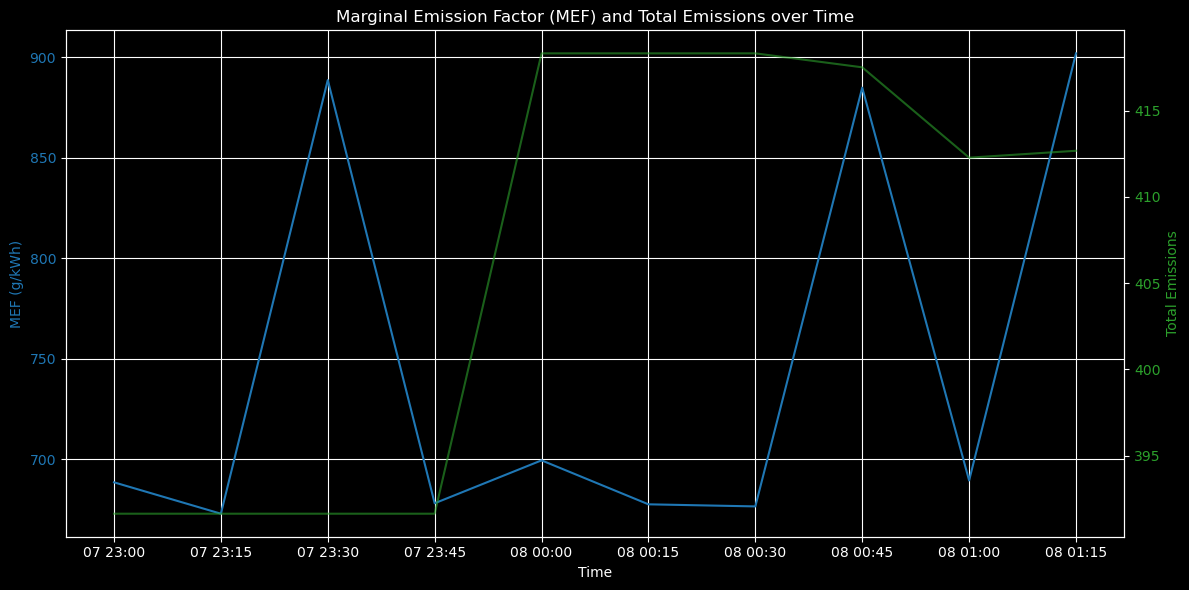

In [27]:
import matplotlib.pyplot as plt

# Create a figure and a primary axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot MEF on the primary axis (left y-axis)
color = 'tab:blue'
ax1.set_xlabel('Time')
ax1.set_ylabel('MEF (g/kWh)', color=color)
ax1.plot(mef.index, mef, color=color, label='MEF (g/kWh)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

# Create a secondary axis sharing the same x-axis
ax2 = ax1.twinx()

# Plot Total Emissions on the secondary axis (right y-axis)
# We need to align the index with mef to ensure same period
total_emissions = analyzer.df.loc[mef.index, 'total_emissions']

color = 'tab:green'
ax2.set_ylabel('Total Emissions', color=color)
ax2.plot(total_emissions.index, total_emissions, color=color, label='Total Emissions (tCO2)', alpha=0.6)
ax2.tick_params(axis='y', labelcolor=color)

# Title and layout
plt.title('Marginal Emission Factor (MEF) and Total Emissions over Time')
fig.tight_layout()  # Adjust the layout to prevent clipping
plt.show()

In [28]:
vars(analyzer)

{'root': PosixPath('/home/aklei/PycharmProjects/marginal-emissions-germany'),
 'tso': 'tennet',
 'run': 'test1',
 'scaler': StandardScaler(),
 'df':                            total_generation  total_emissions
 datetime                                                    
 2022-12-31 23:00:00+00:00            282.75           372.00
 2022-12-31 23:15:00+00:00            282.75           372.00
 2022-12-31 23:30:00+00:00            282.75           372.00
 2022-12-31 23:45:00+00:00            282.75           372.00
 2023-01-01 00:00:00+00:00            281.25           393.16
 ...                                     ...              ...
 2023-01-08 00:15:00+00:00            311.50           418.33
 2023-01-08 00:30:00+00:00            311.50           418.33
 2023-01-08 00:45:00+00:00            311.00           417.52
 2023-01-08 01:00:00+00:00            309.25           412.28
 2023-01-08 01:15:00+00:00            309.50           412.68
 
 [682 rows x 2 columns],
 'window_length': 6